# 03. Master Dataset EDA (Validated-Only Εξερευνητική Ανάλυση Δεδομένων)

## Σκοπός

Το notebook αυτό αποτελεί το **canonical validated-only EDA stage** της ενεργής forecasting pipeline για το DaKS / Kassel dataset.

Το `NB03` **δεν** κάνει raw validation και **δεν** ξανακάνει loose parsing των raw timestamps.
Αυτή η ευθύνη έχει ήδη αναληφθεί από το `02_kassel_exploration.ipynb`, το οποίο λειτουργεί ως το **canonical validation layer**.

## Downstream contract από το NB02

Το `NB03`:

- διαβάζει τα `nb02_*.csv`
- φορτώνει `park_id` ως **string**
- συνεχίζει μόνο με parks όπου `status in {"ok", "warning"}`
- αποκλείει ρητά το failed park `06238`
- βασίζεται στο `NB02` για validation / timestamp integrity
- δεν εφαρμόζει destructive cleaning rules
- δεν κάνει temporal split
- δεν κάνει modeling

## Κύρια outputs

Το notebook παράγει:

1. **validated-only master dataset**
2. **schema summary**
3. **coverage summary**
4. **park-level summary**
5. descriptive visual analytics που λειτουργούν ως γέφυρα προς το feature engineering

## Εκτός scope

Το `NB03` δεν κάνει:

- raw file discovery ως canonical gate
- separator detection
- timestamp format inference
- clipping / outlier removal / heuristic row deletion
- train / validation / test split
- benchmark training ή evaluation

In [1]:
# --------------------------------------------------------------
# NB03 | Imports, path configuration και plotting defaults
# --------------------------------------------------------------

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.notebook import tqdm

# Προσθέτουμε το project root στο sys.path ώστε να είναι ορατό το src/
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data.kassel_loader import KasselLoader

# -----------------------------
# Canonical paths
# -----------------------------
RAW_DIR = ROOT / "data" / "raw" / "kassel_dataset"
PROC_DIR = ROOT / "data" / "processed"

NB02_AUDIT_PATH = PROC_DIR / "nb02_strict_raw_audit.csv"
NB02_STATUS_COUNTS_PATH = PROC_DIR / "nb02_status_counts.csv"
NB02_PAIR_AUDIT_PATH = PROC_DIR / "nb02_pair_audit.csv"
NB02_FAILURE_SUMMARY_PATH = PROC_DIR / "nb02_failure_reason_summary.csv"
META_PATH = RAW_DIR / "meta.csv"

# Δημιουργία processed directory αν δεν υπάρχει
PROC_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Plotting defaults
# -----------------------------
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# -----------------------------
# Canonical NB03 policy
# -----------------------------
VALID_STATUSES = {"ok", "warning"}
EXCLUDED_PARKS = {"06238"}

print("NB03 bootstrap completed.")
print(f"RAW_DIR  : {RAW_DIR}")
print(f"PROC_DIR : {PROC_DIR}")

NB03 bootstrap completed.
RAW_DIR  : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\raw\kassel_dataset
PROC_DIR : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed


## Μεθοδολογική αρχή του NB03

Το park universe του notebook **δεν προκύπτει** από νέο canonical scan του raw directory.
Το canonical eligibility gate προκύπτει **αποκλειστικά** από τα artifacts του `NB02`.

Η raw φόρτωση στο `NB03` χρησιμοποιείται μόνο ως **data transport step** για τα ήδη εγκεκριμένα parks.

Άρα το notebook:

- δεν επαναλαμβάνει το validation logic του `NB02`
- δεν κάνει heuristic parsing από raw strings
- δεν επανεφευρίσκει το park eligibility
- και διασφαλίζει traceability από κάθε downstream artifact πίσω στο `nb02_strict_raw_audit.csv`

In [2]:
# --------------------------------------------------------------
# NB03 | Load NB02 audit artifacts και metadata
# --------------------------------------------------------------

# Φορτώνουμε το canonical raw audit από το NB02.
audit_df = pd.read_csv(
    NB02_AUDIT_PATH,
    dtype={
        "park_id": "string",
        "status": "string",
        "failure_stage": "string",
        "failure_reason": "string",
        "input_file": "string",
        "target_file": "string",
        "input_time_col": "string",
        "target_time_col": "string",
        "input_ts_format_used": "string",
        "target_ts_format_used": "string",
    }
)

# Το park_id πρέπει να είναι πάντα zero-padded string.
audit_df["park_id"] = audit_df["park_id"].str.zfill(5)

status_counts_df = pd.read_csv(
    NB02_STATUS_COUNTS_PATH,
    dtype={"status": "string"}
)

pair_audit_df = pd.read_csv(
    NB02_PAIR_AUDIT_PATH,
    dtype={
        "park_id": "string",
        "pair_status": "string",
        "input_file": "string",
        "target_file": "string",
    }
)
pair_audit_df["park_id"] = pair_audit_df["park_id"].str.zfill(5)

failure_summary_df = pd.read_csv(
    NB02_FAILURE_SUMMARY_PATH,
    dtype={"failure_reason": "string"}
)

# Φορτώνουμε το meta.csv και κανονικοποιούμε το park identifier.
meta_df = pd.read_csv(META_PATH, dtype={"loc_id": "string"})
meta_df["park_id"] = meta_df["loc_id"].str.zfill(5)

print("NB02 status counts:")
display(status_counts_df)

print("NB02 audit preview:")
display(audit_df.head())

print("Metadata preview:")
display(meta_df.head())

NB02 status counts:


,status,parks
0,ok,271
1,failed,1


NB02 audit preview:


,park_id,status,failure_stage,failure_reason,input_file,target_file,input_sep_used,target_sep_used,input_time_col,target_time_col,...,input_monotonic_before_sort,target_monotonic_before_sort,input_min_time,input_max_time,target_min_time,target_max_time,left_only_count,right_only_count,matched_count,exact_timestamp_match
0,00011,ok,<NA>,<NA>,kassel_dataset\data_input_00011.csv,kassel_dataset\data_target_00011.csv,;,",",fcst_time,time,...,True,True,2018-12-08 00:00:00,2020-06-01 23:00:00,2018-12-08 00:00:00,2020-06-01 23:00:00,0.0,0.0,12430.0,True
1,00090,ok,<NA>,<NA>,kassel_dataset\data_input_00090.csv,kassel_dataset\data_target_00090.csv,",",",",fcst_time,time,...,True,True,2018-12-08 00:00:00,2020-06-01 23:00:00,2018-12-08 00:00:00,2020-06-01 23:00:00,0.0,0.0,12822.0,True
2,00096,ok,<NA>,<NA>,kassel_dataset\data_input_00096.csv,kassel_dataset\data_target_00096.csv,",",",",fcst_time,time,...,True,True,2019-04-09 12:00:00,2020-06-01 23:00:00,2019-04-09 12:00:00,2020-06-01 23:00:00,0.0,0.0,9922.0,True
3,00161,ok,<NA>,<NA>,kassel_dataset\data_input_00161.csv,kassel_dataset\data_target_00161.csv,",",",",fcst_time,time,...,True,True,2018-12-08 00:00:00,2020-06-01 23:00:00,2018-12-08 00:00:00,2020-06-01 23:00:00,0.0,0.0,12679.0,True
4,00164,ok,<NA>,<NA>,kassel_dataset\data_input_00164.csv,kassel_dataset\data_target_00164.csv,",",",",fcst_time,time,...,True,True,2018-12-08 00:00:00,2020-06-01 23:00:00,2018-12-08 00:00:00,2020-06-01 23:00:00,0.0,0.0,12817.0,True


Metadata preview:


,loc_id,turbine,hub_height_m,rotor_diameter_m,nominal_power_kW,long,lat,input_file_name,target_file_name,num_train_samples,num_test_samples,park_id
0,06238,E-101,99,101.0,3050.0,11.2500,48.000,data_input_06238.csv,data_target_06238.csv,0,0,06238
1,07308,E-101 E2,74,101.0,3500.0,11.1250,47.875,data_input_07308.csv,data_target_07308.csv,10,0,07308
2,13900,"E-82 E4 (2,35MW)",84,82.0,2350.0,9.3750,50.250,data_input_13900.csv,data_target_13900.csv,44,0,13900
3,03552,E-126 EP4,135,127.0,4200.0,12.8125,52.875,data_input_03552.csv,data_target_03552.csv,2886,0,03552
4,04225,E-126 EP4,135,127.0,4200.0,12.5625,49.250,data_input_04225.csv,data_target_04225.csv,3000,0,04225


In [3]:
# --------------------------------------------------------------
# NB03 | Build canonical validated-only park universe
# --------------------------------------------------------------

# Επιλέγουμε μόνο τα parks που έχουν περάσει το NB02 gate.
eligible_audit_df = audit_df[audit_df["status"].isin(VALID_STATUSES)].copy()

# Ρητός αποκλεισμός του failed park 06238 σύμφωνα με το downstream contract.
eligible_audit_df = eligible_audit_df[
    ~eligible_audit_df["park_id"].isin(EXCLUDED_PARKS)
].copy()

# Canonical park universe για το NB03.
valid_park_ids = sorted(eligible_audit_df["park_id"].unique().tolist())

# -----------------------------
# Strict assertions
# -----------------------------
assert audit_df["park_id"].isna().sum() == 0, "Missing park_id detected in NB02 audit."
assert eligible_audit_df["park_id"].duplicated().sum() == 0, "Duplicate park_id rows found in eligible NB02 audit."
assert "06238" not in valid_park_ids, "Failed park 06238 leaked into NB03 universe."
assert set(eligible_audit_df["status"].dropna().unique()).issubset(VALID_STATUSES), "Unexpected status found in NB03 eligible set."

print(f"Eligible parks for NB03: {len(valid_park_ids)}")
print(f"First 10 park_ids: {valid_park_ids[:10]}")
print(f"Last 10 park_ids : {valid_park_ids[-10:]}")

Eligible parks for NB03: 271
First 10 park_ids: ['00011', '00090', '00096', '00161', '00164', '00183', '00197', '00198', '00232', '00282']
Last 10 park_ids : ['15189', '15190', '15200', '15207', '15214', '15444', '15520', '15547', '15976', '15978']


## Validated-only loading strategy

Σε αυτό το στάδιο γίνεται φόρτωση μόνο των parks που έχουν ήδη εγκριθεί από το `NB02`.

Σημαντικές αρχές:

- το `park_id` παραμένει **string**
- το `timestamp` διατηρείται ως **explicit column**
- το notebook **δεν** εφαρμόζει row filtering heuristics
- το notebook **δεν** κάνει "καθάρισμα" που αλλοιώνει το canonical validated dataset

Το `NB03` είναι **descriptive / analytical notebook**, όχι preprocessing notebook.

In [4]:
# --------------------------------------------------------------
# NB03 | Helper utilities για strict transport normalization
# --------------------------------------------------------------

def normalize_loaded_park_frame(df: pd.DataFrame, park_id: str) -> pd.DataFrame:
    """
    Κανονικοποιεί το frame που επιστρέφει ο loader χωρίς να εφαρμόζει
    νέο raw parsing logic.

    Βασική αρχή:
    - Αν ο loader επιστρέφει DatetimeIndex, τον μετατρέπουμε σε explicit column.
    - Αν υπάρχει ήδη timestamp column σε datetime dtype, τη διατηρούμε.
    - Αν ο χρόνος ΔΕΝ είναι ήδη datetime-like, το NB03 αποτυγχάνει ρητά,
      γιατί δεν επιτρέπεται loose reparsing σε αυτό το stage.
    """
    if df is None or df.empty:
        raise ValueError(f"Validated park {park_id} returned empty data.")

    df = df.copy()

    # Περίπτωση 1: ο χρόνος βρίσκεται σε DatetimeIndex.
    if isinstance(df.index, pd.DatetimeIndex):
        index_name = df.index.name if df.index.name is not None else "timestamp"
        df = df.reset_index().rename(columns={index_name: "timestamp"})

    # Περίπτωση 2: υπάρχει explicit timestamp column.
    elif "timestamp" in df.columns:
        pass

    # Οποιαδήποτε άλλη περίπτωση θεωρείται methodological violation για το NB03.
    else:
        raise TypeError(
            f"Park {park_id} does not expose a datetime index or a canonical timestamp column. "
            "NB03 is not allowed to perform loose timestamp reparsing."
        )

    # Ελέγχουμε ότι το timestamp είναι ήδη datetime-like.
    if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        raise TypeError(
            f"Park {park_id} timestamp is not datetime-like after loader transport. "
            "NB03 expects canonical time handling upstream."
        )

    # Επιβάλλουμε canonical park_id representation.
    df["park_id"] = str(park_id).zfill(5)

    # Ταξινόμηση σε park-time order για deterministic downstream behavior.
    df = df.sort_values("timestamp").reset_index(drop=True)

    return df


def resolve_first_available_column(columns, candidates, purpose: str):
    """
    Επιστρέφει την πρώτη διαθέσιμη στήλη από μια λίστα candidates.
    Χρήσιμο για robust EDA όταν μπορεί να υπάρχουν μικρές διαφοροποιήσεις naming.
    """
    for candidate in candidates:
        if candidate in columns:
            return candidate

    raise KeyError(
        f"Could not resolve a column for {purpose}. "
        f"Tried candidates: {candidates}"
    )

In [5]:
# --------------------------------------------------------------
# NB03 | Load only NB02-approved parks
# --------------------------------------------------------------

loader = KasselLoader(str(RAW_DIR))

park_frames = []

for park_id in tqdm(valid_park_ids, desc="Loading NB02-approved parks"):
    raw_df = loader.load_park_data(park_id)
    park_df = normalize_loaded_park_frame(raw_df, park_id)
    park_frames.append(park_df)

# Ενώνουμε όλα τα validated park frames σε ένα canonical master dataset.
master_df = pd.concat(park_frames, ignore_index=True)

# Canonical dtypes
master_df["park_id"] = master_df["park_id"].astype("string").str.zfill(5)

# -----------------------------
# Resolve key analytical columns
# -----------------------------
TARGET_COL = resolve_first_available_column(
    master_df.columns,
    candidates=["Power_Output_Normalized"],
    purpose="target variable"
)

WIND_COL = resolve_first_available_column(
    master_df.columns,
    candidates=["Wind_Speed_100m_ms", "ws_ref"],
    purpose="wind-related feature"
)

BASELINE_COL = None
for candidate in ["Baseline_Prediction", "baseline_prediction", "power_curve_prediction"]:
    if candidate in master_df.columns:
        BASELINE_COL = candidate
        break

# -----------------------------
# Merge metadata και NB02 status
# -----------------------------
meta_keep_cols = [
    "park_id",
    "turbine",
    "hub_height_m",
    "rotor_diameter_m",
    "nominal_power_kW",
    "long",
    "lat",
    "num_train_samples",
    "num_test_samples",
]

master_df = master_df.merge(
    meta_df[meta_keep_cols],
    on="park_id",
    how="left",
    validate="many_to_one"
)

master_df = master_df.merge(
    eligible_audit_df[["park_id", "status"]].rename(columns={"status": "nb02_status"}),
    on="park_id",
    how="left",
    validate="many_to_one"
)

# -----------------------------
# Strict post-load checks
# -----------------------------
assert master_df["park_id"].isna().sum() == 0, "Missing park_id detected after load."
assert master_df["timestamp"].isna().sum() == 0, "Missing timestamp detected after load."
assert master_df["nb02_status"].isin(VALID_STATUSES).all(), "Unexpected NB02 status found after merge."
assert master_df["park_id"].nunique() == len(valid_park_ids), "Mismatch between eligible parks and loaded parks."

# Deterministic ordering
master_df = master_df.sort_values(["park_id", "timestamp"]).reset_index(drop=True)

print("Master dataset successfully created.")
print(f"Rows  : {len(master_df):,}")
print(f"Parks : {master_df['park_id'].nunique():,}")
print(f"Target column   : {TARGET_COL}")
print(f"Wind column     : {WIND_COL}")
print(f"Baseline column : {BASELINE_COL}")
display(master_df.head())

KasselLoader Initialized: Καταλογογραφήθηκαν 273 πάρκα.


Loading NB02-approved parks:   0%|          | 0/271 [00:00<?, ?it/s]

Master dataset successfully created.
Rows  : 3,355,233
Parks : 271
Target column   : Power_Output_Normalized
Wind column     : Wind_Speed_100m_ms
Baseline column : Baseline_Prediction


,timestamp,fcst_time,nwp_fcst_horiz_hours,T_HAG_2_M,RELHUM_HAG_2_M,PS_SFC_0_M,U_GVL_58_HL,V_GVL_58_HL,U_GVL_60_HL,V_GVL_60_HL,...,park_id,turbine,hub_height_m,rotor_diameter_m,nominal_power_kW,long,lat,num_train_samples,num_test_samples,nb02_status
0,2018-12-12 00:00:00,12/12/2018 0:00,24,269725.0,92373.0,93686352.0,127.0,-354.0,422.0,-120.0,...,00011,"E-82 E4 (2,35MW)",84,82.0,2350.0,8.5,48.0,8140,4290,ok
1,2018-12-12 01:00:00,12/12/2018 1:00,25,269547.0,91783.0,93673273.0,193.0,-641.0,538.0,-99.0,...,00011,"E-82 E4 (2,35MW)",84,82.0,2350.0,8.5,48.0,8140,4290,ok
2,2018-12-12 02:00:00,12/12/2018 2:00,26,269285.0,91758.0,93675902.0,152.0,-380.0,487.0,58.0,...,00011,"E-82 E4 (2,35MW)",84,82.0,2350.0,8.5,48.0,8140,4290,ok
3,2018-12-12 03:00:00,12/12/2018 3:00,27,269198.0,91159.0,93641559.0,-90.0,-378.0,420.0,-4.0,...,00011,"E-82 E4 (2,35MW)",84,82.0,2350.0,8.5,48.0,8140,4290,ok
4,2018-12-12 04:00:00,12/12/2018 4:00,28,269304.0,90048.0,93654922.0,-20.0,-465.0,452.0,-80.0,...,00011,"E-82 E4 (2,35MW)",84,82.0,2350.0,8.5,48.0,8140,4290,ok


In [6]:
# --------------------------------------------------------------
# NB03 | Dataset-level overview και integrity checks
# --------------------------------------------------------------

print("Dataset-level overview")
print("-" * 60)
print(f"Rows                    : {len(master_df):,}")
print(f"Parks                   : {master_df['park_id'].nunique():,}")
print(f"Timestamp min           : {master_df['timestamp'].min()}")
print(f"Timestamp max           : {master_df['timestamp'].max()}")
print(f"Columns                 : {len(master_df.columns)}")

# Duplicate key check σε επίπεδο park_id + timestamp
duplicate_key_count = master_df.duplicated(subset=["park_id", "timestamp"]).sum()
print(f"Duplicate (park_id, timestamp) rows : {duplicate_key_count}")

# Missing values summary
null_summary = (
    master_df.isna()
    .sum()
    .rename("null_count")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "column"})
)

print("\nColumns with missing values:")
display(null_summary[null_summary["null_count"] > 0])

print("\nCore descriptive statistics:")
stats_cols = [TARGET_COL, WIND_COL]
if BASELINE_COL is not None:
    stats_cols.append(BASELINE_COL)

display(master_df[stats_cols].describe())

print("\nDtype summary:")
display(
    pd.DataFrame({
        "column": master_df.columns,
        "dtype": [str(master_df[col].dtype) for col in master_df.columns]
    })
)

Dataset-level overview
------------------------------------------------------------
Rows                    : 3,355,233
Parks                   : 271
Timestamp min           : 2018-01-25 00:00:00
Timestamp max           : 2020-12-05 23:00:00
Columns                 : 35
Duplicate (park_id, timestamp) rows : 0

Columns with missing values:


,column,null_count



Core descriptive statistics:


,Power_Output_Normalized,Wind_Speed_100m_ms,Baseline_Prediction
count,3.355233e+06,3.355233e+06,3.355233e+06
mean,1.898031e-01,2.129941e-02,2.451502e-01
std,2.842895e-01,3.242343e-01,3.117728e-01
min,0.000000e+00,2.162020e-06,0.000000e+00
25%,6.000000e-03,3.114816e-03,9.000000e-03
50%,5.300000e-02,5.857609e-03,9.300000e-02
75%,2.340000e-01,9.004925e-03,3.770000e-01
max,1.025000e+00,2.383275e+01,1.025000e+00



Dtype summary:


,column,dtype
0,timestamp,datetime64[us]
1,fcst_time,str
2,nwp_fcst_horiz_hours,int64
3,T_HAG_2_M,float64
4,RELHUM_HAG_2_M,float64
5,PS_SFC_0_M,float64
6,U_GVL_58_HL,float64
7,V_GVL_58_HL,float64
8,U_GVL_60_HL,float64
9,V_GVL_60_HL,float64


In [7]:
# --------------------------------------------------------------
# NB03 | Schema summary, coverage summary και park-level summary
# --------------------------------------------------------------

# -----------------------------
# Schema summary
# -----------------------------
schema_summary_df = pd.DataFrame({
    "column": master_df.columns,
    "dtype": [str(master_df[col].dtype) for col in master_df.columns],
    "null_count": [int(master_df[col].isna().sum()) for col in master_df.columns],
    "null_ratio": [float(master_df[col].isna().mean()) for col in master_df.columns],
    "nunique": [int(master_df[col].nunique(dropna=True)) for col in master_df.columns],
})

# -----------------------------
# Coverage summary
# -----------------------------
coverage_summary_df = pd.DataFrame({
    "metric": [
        "rows",
        "parks",
        "timestamp_min",
        "timestamp_max",
        "duplicate_park_timestamp_rows",
    ],
    "value": [
        len(master_df),
        master_df["park_id"].nunique(),
        master_df["timestamp"].min(),
        master_df["timestamp"].max(),
        duplicate_key_count,
    ]
})

# -----------------------------
# Park-level summary
# -----------------------------
park_level_summary_df = (
    master_df.groupby("park_id", dropna=False)
    .agg(
        rows=("park_id", "size"),
        timestamp_min=("timestamp", "min"),
        timestamp_max=("timestamp", "max"),
        target_missing=(TARGET_COL, lambda s: int(s.isna().sum())),
        wind_missing=(WIND_COL, lambda s: int(s.isna().sum())),
        target_mean=(TARGET_COL, "mean"),
        target_std=(TARGET_COL, "std"),
        wind_mean=(WIND_COL, "mean"),
        wind_std=(WIND_COL, "std"),
        turbine=("turbine", "first"),
        hub_height_m=("hub_height_m", "first"),
        rotor_diameter_m=("rotor_diameter_m", "first"),
        nominal_power_kW=("nominal_power_kW", "first"),
        nb02_status=("nb02_status", "first"),
    )
    .reset_index()
    .sort_values("park_id")
)

# Αν υπάρχει baseline column, προσθέτουμε baseline summary metrics.
if BASELINE_COL is not None:
    baseline_summary = (
        master_df.groupby("park_id")[BASELINE_COL]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "baseline_mean", "std": "baseline_std"})
    )
    park_level_summary_df = park_level_summary_df.merge(
        baseline_summary,
        on="park_id",
        how="left",
        validate="one_to_one"
    )

print("Schema summary preview:")
display(schema_summary_df.head(10))

print("Coverage summary:")
display(coverage_summary_df)

print("Park-level summary preview:")
display(park_level_summary_df.head())

Schema summary preview:


,column,dtype,null_count,null_ratio,nunique
0,timestamp,datetime64[us],0,0.0,12850
1,fcst_time,str,0,0.0,24315
2,nwp_fcst_horiz_hours,int64,0,0.0,24
3,T_HAG_2_M,float64,0,0.0,55594
4,RELHUM_HAG_2_M,float64,0,0.0,88477
5,PS_SFC_0_M,float64,0,0.0,1936335
6,U_GVL_58_HL,float64,0,0.0,42741
7,V_GVL_58_HL,float64,0,0.0,41452
8,U_GVL_60_HL,float64,0,0.0,31680
9,V_GVL_60_HL,float64,0,0.0,31063


Coverage summary:


,metric,value
0,rows,3355233
1,parks,271
2,timestamp_min,2018-01-25 00:00:00
3,timestamp_max,2020-12-05 23:00:00
4,duplicate_park_timestamp_rows,0


Park-level summary preview:


,park_id,rows,timestamp_min,timestamp_max,target_missing,wind_missing,target_mean,target_std,wind_mean,wind_std,turbine,hub_height_m,rotor_diameter_m,nominal_power_kW,nb02_status,baseline_mean,baseline_std
0,00011,11465,2018-12-12,2020-06-01 23:00:00,0,0,0.082305,0.152052,4.360169,3.445502,"E-82 E4 (2,35MW)",84,82.0,2350.0,ok,0.112176,0.222135
1,00090,12822,2018-08-12,2020-12-05 23:00:00,0,0,0.126065,0.220049,0.005903,0.003794,E-70 E4,114,71.0,2300.0,ok,0.185951,0.267466
2,00096,9922,2019-01-05,2020-12-05 23:00:00,0,0,0.094102,0.157532,0.007326,0.003140,E-115,149,115.7,3000.0,ok,0.422978,0.330149
3,00161,12679,2018-08-12,2020-12-05 23:00:00,0,0,0.083090,0.162467,0.004514,0.003367,E-115,92,115.7,3000.0,ok,0.165573,0.267627
4,00164,12817,2018-08-12,2020-12-05 23:00:00,0,0,0.156188,0.218705,0.007341,0.003272,E-101 E2,74,101.0,3500.0,ok,0.256662,0.264433


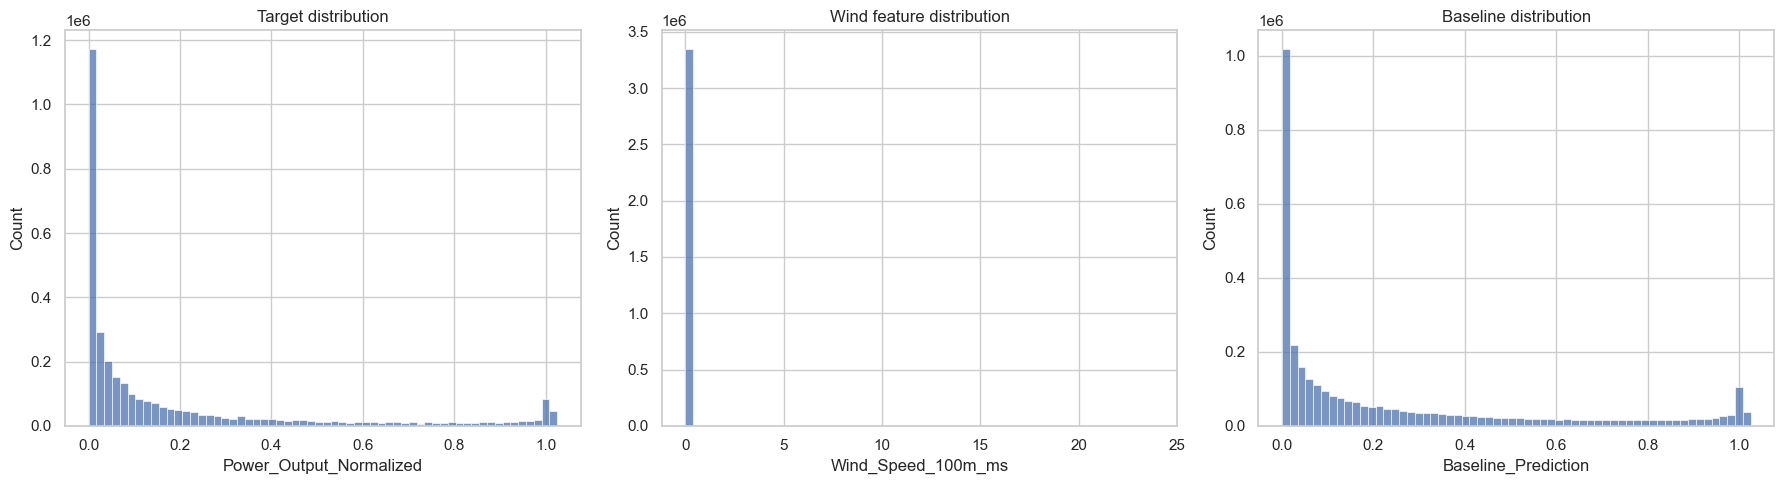

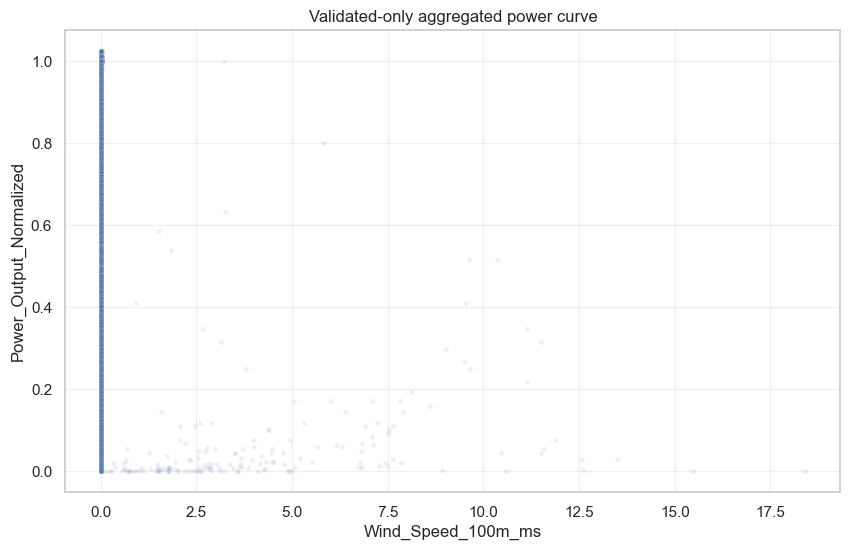

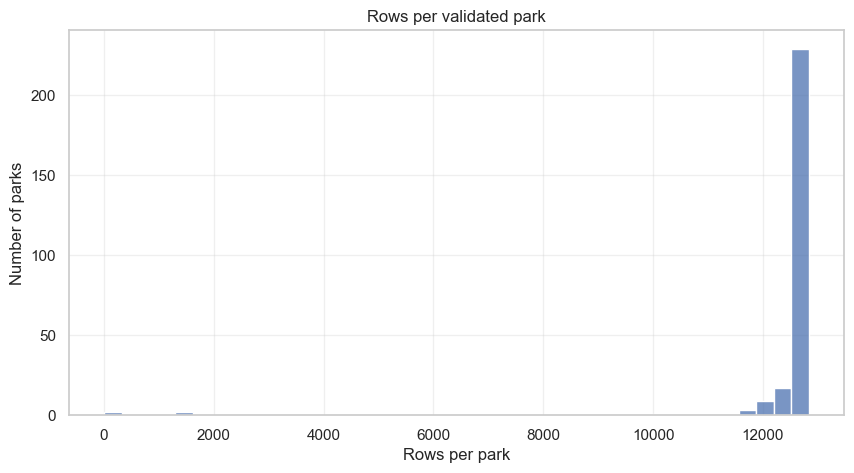

In [8]:
# --------------------------------------------------------------
# NB03 | Descriptive visual analytics
# --------------------------------------------------------------

# Για plotting χρησιμοποιούμε δείγμα ώστε να είναι ελαφρύτερο το notebook
# χωρίς να αλλοιώνεται το canonical dataset.
plot_sample_n = min(50_000, len(master_df))
plot_sample_df = master_df.sample(n=plot_sample_n, random_state=42)

# -----------------------------
# Distribution plots
# -----------------------------
fig, axes = plt.subplots(1, 3 if BASELINE_COL is not None else 2, figsize=(18, 5))

sns.histplot(master_df[TARGET_COL], bins=60, ax=axes[0])
axes[0].set_title("Target distribution")
axes[0].set_xlabel(TARGET_COL)

sns.histplot(master_df[WIND_COL], bins=60, ax=axes[1])
axes[1].set_title("Wind feature distribution")
axes[1].set_xlabel(WIND_COL)

if BASELINE_COL is not None:
    sns.histplot(master_df[BASELINE_COL], bins=60, ax=axes[2])
    axes[2].set_title("Baseline distribution")
    axes[2].set_xlabel(BASELINE_COL)

plt.tight_layout()
plt.show()

# -----------------------------
# Aggregated power curve
# -----------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample_df,
    x=WIND_COL,
    y=TARGET_COL,
    alpha=0.10,
    s=12,
)

plt.title("Validated-only aggregated power curve")
plt.xlabel(WIND_COL)
plt.ylabel(TARGET_COL)
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Park coverage distribution
# -----------------------------
plt.figure(figsize=(10, 5))
sns.histplot(park_level_summary_df["rows"], bins=40)
plt.title("Rows per validated park")
plt.xlabel("Rows per park")
plt.ylabel("Number of parks")
plt.grid(alpha=0.3)
plt.show()

Time-series inspection park_id: 00011
Inspection window rows        : 240


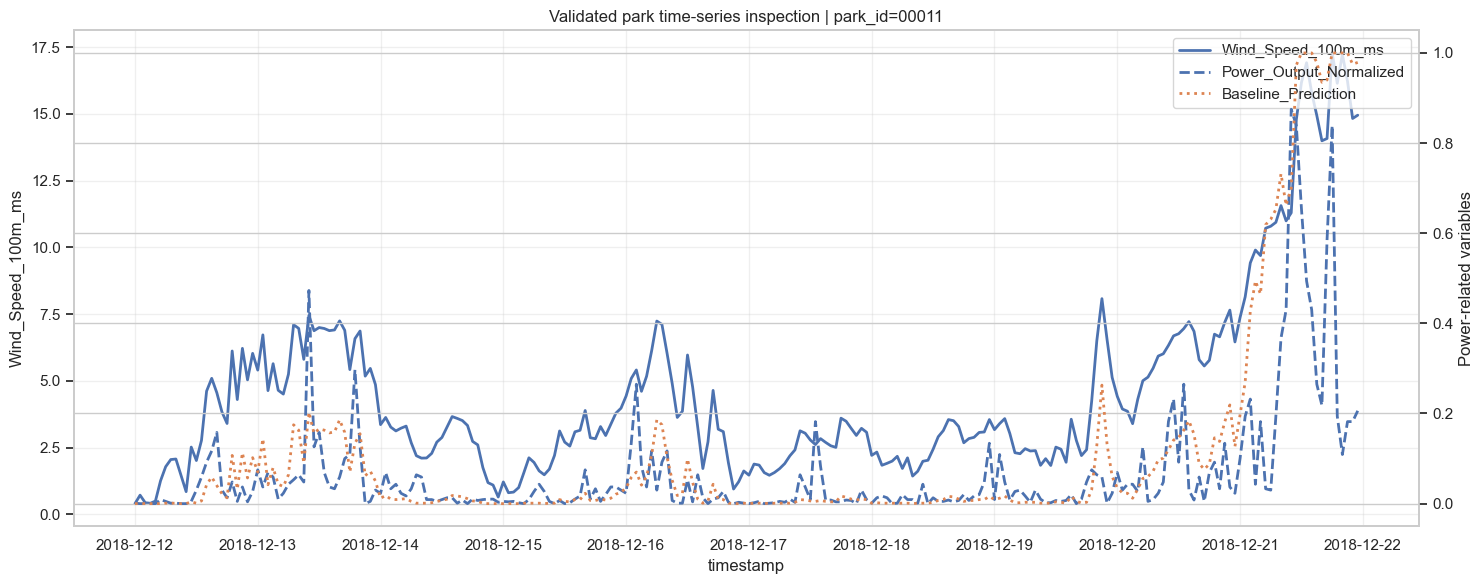

In [9]:
# --------------------------------------------------------------
# NB03 | Park-level time-series inspection
# --------------------------------------------------------------

# Επιλέγουμε deterministic park για inspection.
# Αν υπάρχει το 00011, το προτιμάμε ως γνωστό reference park.
preferred_park_id = "00011"
park_id_check = (
    preferred_park_id
    if preferred_park_id in set(master_df["park_id"].unique())
    else park_level_summary_df.sort_values("rows", ascending=False)["park_id"].iloc[0]
)

df_check = (
    master_df[master_df["park_id"] == park_id_check]
    .sort_values("timestamp")
    .copy()
)

# Παίρνουμε ένα αντιπροσωπευτικό παράθυρο παρατήρησης.
window_size = min(240, len(df_check))
subset = df_check.iloc[:window_size].copy()

print(f"Time-series inspection park_id: {park_id_check}")
print(f"Inspection window rows        : {len(subset)}")

fig, ax1 = plt.subplots(figsize=(15, 6))

# Αριστερός άξονας: wind-related input
ax1.plot(
    subset["timestamp"],
    subset[WIND_COL],
    linewidth=2,
    label=WIND_COL
)
ax1.set_xlabel("timestamp")
ax1.set_ylabel(WIND_COL)
ax1.grid(alpha=0.3)

# Δεξιός άξονας: target και προαιρετικά baseline
ax2 = ax1.twinx()
ax2.plot(
    subset["timestamp"],
    subset[TARGET_COL],
    linestyle="--",
    linewidth=2,
    label=TARGET_COL
)

if BASELINE_COL is not None:
    ax2.plot(
        subset["timestamp"],
        subset[BASELINE_COL],
        linestyle=":",
        linewidth=2,
        label=BASELINE_COL
    )

ax2.set_ylabel("Power-related variables")

# Συνδυασμός legends από τους δύο άξονες
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title(f"Validated park time-series inspection | park_id={park_id_check}")
fig.tight_layout()
plt.show()

In [10]:
# --------------------------------------------------------------
# NB03 | Export canonical validated-only artifacts
# --------------------------------------------------------------

master_export_path = PROC_DIR / "master_dataset.csv"
schema_export_path = PROC_DIR / "nb03_schema_summary.csv"
coverage_export_path = PROC_DIR / "nb03_coverage_summary.csv"
park_summary_export_path = PROC_DIR / "nb03_park_level_summary.csv"

# Αποθηκεύουμε τα canonical outputs του NB03.
master_df.to_csv(master_export_path, index=False)
schema_summary_df.to_csv(schema_export_path, index=False)
coverage_summary_df.to_csv(coverage_export_path, index=False)
park_level_summary_df.to_csv(park_summary_export_path, index=False)

print("NB03 exports completed successfully.")
print(f"Saved: {master_export_path}")
print(f"Saved: {schema_export_path}")
print(f"Saved: {coverage_export_path}")
print(f"Saved: {park_summary_export_path}")

NB03 exports completed successfully.
Saved: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\master_dataset.csv
Saved: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\nb03_schema_summary.csv
Saved: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\nb03_coverage_summary.csv
Saved: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\nb03_park_level_summary.csv


## Συμπέρασμα

Το `NB03` παρήγαγε το **canonical validated-only master dataset** της ενεργής forecasting pipeline.

Το notebook:

- βασίστηκε αποκλειστικά στο `NB02` ως validation gate
- φόρτωσε μόνο parks με `status in {"ok", "warning"}`
- απέκλεισε ρητά το failed park `06238`
- διατήρησε το `park_id` ως string
- διατήρησε το `timestamp` ως explicit temporal key
- δεν εισήγαγε destructive cleaning decisions
- και παρήγαγε reproducible descriptive summaries για downstream χρήση

## Downstream bridge προς NB04

Το `NB04` πρέπει πλέον να ξεκινά από το `master_dataset.csv` του `NB03` και όχι από νέο raw discovery.

Άρα η σωστή pipeline συνέχεια είναι:

`NB02 raw validation -> NB03 validated-only EDA -> NB04 feature engineering -> NB05 split / leakage-aware processing -> NB06 / NB07 modeling`